# 04 Model Training

Train tuned baseline models plus a simple Logistic Regression + LightGBM hybrid, compare their metrics, and save report-ready tables and figures.

In [5]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

from evaluation import (
    blend_probabilities,
    build_precision_recall_curve_df,
    evaluate_predictions,
    evaluate_with_best_f1_threshold,
    find_threshold_for_target_precision,
)
from models import (
    tune_lightgbm_baseline,
    tune_logistic_regression_baseline,
    tune_mlp_baseline,
    tune_random_forest_baseline,
)

In [6]:
processed_dir = PROJECT_ROOT / "data" / "processed"
tables_dir = PROJECT_ROOT / "outputs" / "tables"
figures_dir = PROJECT_ROOT / "outputs" / "figures"
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

train_linear = pd.read_parquet(processed_dir / "train_linear_ready.parquet")
train_tree = pd.read_parquet(processed_dir / "train_tree_ready.parquet")

print("Linear-ready shape:", train_linear.shape)
print("Tree-ready shape:", train_tree.shape)

Linear-ready shape: (307511, 600)
Tree-ready shape: (307511, 600)


## Tuned Baseline Models

In [8]:
# Previous Logistic Regression grid search:
# log_reg_param_grid = {
#     "C": [0.1, 1.0, 5.0],
# }

log_reg_param_grid = {
    "C": [5.0],
}

log_reg_model, log_reg_results, y_val_log_reg, log_reg_probs, log_reg_tuning_results, best_log_reg_params = tune_logistic_regression_baseline(
    param_grid=log_reg_param_grid
)

print("Best Logistic Regression params:", best_log_reg_params)
print("Logistic Regression Results:")
for metric, value in log_reg_results.items():
    if metric != "model":
        print(f"{metric}: {value:.4f}")

Best Logistic Regression params: {'C': 5.0}
Logistic Regression Results:
accuracy: 0.7111
precision: 0.1757
recall: 0.6985
f1: 0.2808
roc_auc: 0.7753
average_precision: 0.2636


In [9]:
# Previous Random Forest grid search:
# rf_param_grid = {
#     "n_estimators": [200, 400],
#     "max_depth": [12, 20, None],
#     "min_samples_leaf": [5, 10],
#     "min_samples_split": [10, 20],
# }

rf_param_grid = {
    "n_estimators": [400],
    "max_depth": [None],
    "min_samples_leaf": [10],
    "min_samples_split": [10],
}

rf_model, rf_results, y_val_rf, rf_probs, rf_tuning_results, best_rf_params = tune_random_forest_baseline(
    param_grid=rf_param_grid
)

print("Best Random Forest params:", best_rf_params)
print("Random Forest Results:")
for metric, value in rf_results.items():
    if metric != "model":
        print(f"{metric}: {value:.4f}")

Best Random Forest params: {'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 400}
Random Forest Results:
accuracy: 0.9111
precision: 0.3771
recall: 0.1555
f1: 0.2202
roc_auc: 0.7707
average_precision: 0.2548


In [10]:
# Previous LightGBM grid search:
# lgbm_param_grid = {
#     "n_estimators": [300, 500],
#     "learning_rate": [0.03, 0.05],
#     "num_leaves": [31, 64, 96],
#     "min_child_samples": [20, 50],
# }

lgbm_param_grid = {
    "learning_rate": [0.03],
    "min_child_samples": [50],
    "n_estimators": [500],
    "num_leaves": [64],
}

lgbm_model, lgbm_results, y_val_lgbm, lgbm_probs, lgbm_tuning_results, best_lgbm_params = tune_lightgbm_baseline(
    param_grid=lgbm_param_grid
)

print("Best LightGBM params:", best_lgbm_params)
print("LightGBM Results:")
for metric, value in lgbm_results.items():
    if metric != "model":
        print(f"{metric}: {value:.4f}")

Best LightGBM params: {'learning_rate': 0.03, 'min_child_samples': 50, 'n_estimators': 500, 'num_leaves': 64}
LightGBM Results:
accuracy: 0.7657
precision: 0.2044
recall: 0.6574
f1: 0.3118
roc_auc: 0.7893
average_precision: 0.2881


In [11]:
# Previous Neural Network grid search:
# mlp_param_grid = {
#     "hidden_dims": [(256, 128), (128, 64), (256, 64)],
#     "dropout": [0.2, 0.3],
#     "learning_rate": [0.001, 0.0005],
#     "epochs": [15, 20],
# }

mlp_param_grid = {
    "hidden_dims": [(128, 64)],
    "dropout": [0.3],
    "learning_rate": [0.0005],
    "epochs": [15],
}

mlp_model, mlp_results, mlp_history, y_val_mlp, mlp_probs, mlp_tuning_results, best_mlp_params = tune_mlp_baseline(
    param_grid=mlp_param_grid
)

print("Best Neural Network params:", best_mlp_params)
print("Neural Network Results:")
for metric, value in mlp_results.items():
    if metric != "model":
        print(f"{metric}: {value:.4f}")

mlp_history.tail()

Best Neural Network params: {'dropout': 0.3, 'epochs': 15, 'hidden_dims': (128, 64), 'learning_rate': 0.0005}
Neural Network Results:
accuracy: 0.6945
precision: 0.1706
recall: 0.7210
f1: 0.2759
roc_auc: 0.7735
average_precision: 0.2719


,epoch,train_loss
10,11,1.002155
11,12,0.991706
12,13,0.987543
13,14,0.978042
14,15,0.974228


## Hybrid Model

The hybrid model is the project's novel contribution. It blends tuned Logistic Regression and tuned LightGBM validation probabilities with a fixed weight sweep.

In [12]:
hybrid_y_val = y_val_log_reg.reset_index(drop=True)
if not hybrid_y_val.equals(y_val_lgbm.reset_index(drop=True)):
    raise ValueError("Validation labels do not align between Logistic Regression and LightGBM.")

hybrid_rows = []
for lgbm_weight in [0.50, 0.60, 0.70, 0.80, 0.90]:
    hybrid_probs_candidate = blend_probabilities(lgbm_probs, log_reg_probs, primary_weight=lgbm_weight)
    default_metrics = evaluate_predictions(hybrid_y_val, hybrid_probs_candidate)
    tuned_metrics = evaluate_with_best_f1_threshold(hybrid_y_val, hybrid_probs_candidate)
    hybrid_rows.append(
        {
            "lgbm_weight": lgbm_weight,
            "log_reg_weight": 1 - lgbm_weight,
            "roc_auc": default_metrics["roc_auc"],
            "average_precision": default_metrics["average_precision"],
            "default_f1": default_metrics["f1"],
            "tuned_f1": tuned_metrics["f1"],
            "tuned_precision": tuned_metrics["precision"],
            "tuned_recall": tuned_metrics["recall"],
            "tuned_threshold": tuned_metrics["threshold"],
        }
    )

hybrid_weight_df = pd.DataFrame(hybrid_rows)
hybrid_weight_df = hybrid_weight_df.sort_values(["roc_auc", "tuned_f1"], ascending=False).reset_index(drop=True)
hybrid_weight_df

,lgbm_weight,log_reg_weight,roc_auc,average_precision,default_f1,tuned_f1,tuned_precision,tuned_recall,tuned_threshold
0,0.8,0.2,0.790512,0.290986,0.309587,0.345597,0.279681,0.452165,0.65
1,0.7,0.3,0.790417,0.291193,0.307941,0.345837,0.278248,0.456798,0.65
2,0.9,0.1,0.790121,0.290062,0.309442,0.343584,0.267061,0.481571,0.63
3,0.6,0.4,0.789831,0.290373,0.305958,0.345556,0.276270,0.461229,0.65
4,0.5,0.5,0.788730,0.288690,0.302368,0.343857,0.272770,0.465055,0.65


In [13]:
best_hybrid_row = hybrid_weight_df.iloc[0]
best_lgbm_weight = float(best_hybrid_row["lgbm_weight"])
hybrid_probs = blend_probabilities(lgbm_probs, log_reg_probs, primary_weight=best_lgbm_weight)

hybrid_results = {
    "model": f"Hybrid (LGBM {best_lgbm_weight:.1f} + LR {1 - best_lgbm_weight:.1f})",
    **evaluate_predictions(hybrid_y_val, hybrid_probs),
}

hybrid_tuned_results = {
    "model": hybrid_results["model"],
    **evaluate_with_best_f1_threshold(hybrid_y_val, hybrid_probs),
}

pd.Series(hybrid_tuned_results)

model                 Hybrid (LGBM 0.8 + LR 0.2)
accuracy                                0.861763
precision                               0.279681
recall                                  0.452165
f1                                      0.345597
roc_auc                                 0.790512
average_precision                       0.290986
threshold                                   0.65
best_f1_from_sweep                      0.345597
dtype: object

## Model Comparison

In [14]:
log_reg_tuned_results = {
    "model": "Logistic Regression",
    **evaluate_with_best_f1_threshold(y_val_log_reg, log_reg_probs),
}

rf_tuned_results = {
    "model": "Random Forest",
    **evaluate_with_best_f1_threshold(y_val_rf, rf_probs),
}

lgbm_tuned_results = {
    "model": "LightGBM",
    **evaluate_with_best_f1_threshold(y_val_lgbm, lgbm_probs),
}

mlp_tuned_results = {
    "model": "Neural Network",
    **evaluate_with_best_f1_threshold(y_val_mlp, mlp_probs),
}

tuned_results_df = pd.DataFrame([
    log_reg_tuned_results,
    rf_tuned_results,
    lgbm_tuned_results,
    mlp_tuned_results,
    hybrid_tuned_results,
])
tuned_results_df = tuned_results_df.sort_values(["average_precision", "roc_auc", "f1"], ascending=False).reset_index(drop=True)
tuned_results_df

,model,accuracy,precision,recall,f1,roc_auc,average_precision,threshold,best_f1_from_sweep
0,Hybrid (LGBM 0.8 + LR 0.2),0.861763,0.279681,0.452165,0.345597,0.790512,0.290986,0.65,0.345597
1,LightGBM,0.851828,0.266284,0.475932,0.341499,0.789275,0.288121,0.63,0.341499
2,Neural Network,0.851162,0.261038,0.460826,0.333285,0.773487,0.271914,0.67,0.333285
3,Logistic Regression,0.865063,0.276601,0.415710,0.332180,0.775264,0.263563,0.70,0.332180
4,Random Forest,0.851747,0.252827,0.427795,0.317821,0.770708,0.254767,0.35,0.317821


In [15]:
results_df = pd.DataFrame([
    log_reg_results,
    rf_results,
    lgbm_results,
    mlp_results,
    hybrid_results,
])
results_df = results_df.sort_values(["average_precision", "roc_auc", "f1"], ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Hybrid (LGBM 0.8 + LR 0.2),0.759378,0.201457,0.668278,0.309587,0.790512,0.290986
1,LightGBM,0.765735,0.204370,0.657402,0.311807,0.789275,0.288121
2,Neural Network,0.694519,0.170614,0.721047,0.275936,0.773487,0.271914
3,Logistic Regression,0.711087,0.175684,0.698489,0.280753,0.775264,0.263563
4,Random Forest,0.911094,0.377137,0.155488,0.220194,0.770708,0.254767


In [16]:
results_df.to_csv(tables_dir / "model_metrics_default.csv", index=False)
tuned_results_df.to_csv(tables_dir / "model_metrics_tuned.csv", index=False)
hybrid_weight_df.to_csv(tables_dir / "hybrid_weight_sweep.csv", index=False)
log_reg_tuning_results.to_csv(tables_dir / "logistic_regression_tuning_results.csv", index=False)
rf_tuning_results.to_csv(tables_dir / "random_forest_tuning_results.csv", index=False)
lgbm_tuning_results.to_csv(tables_dir / "lightgbm_tuning_results.csv", index=False)
mlp_tuning_results.to_csv(tables_dir / "neural_net_tuning_results.csv", index=False)

print(tables_dir / "model_metrics_default.csv")
print(tables_dir / "model_metrics_tuned.csv")
print(tables_dir / "hybrid_weight_sweep.csv")
print(tables_dir / "logistic_regression_tuning_results.csv")
print(tables_dir / "random_forest_tuning_results.csv")
print(tables_dir / "lightgbm_tuning_results.csv")
print(tables_dir / "neural_net_tuning_results.csv")

/mnt/c/Users/arand/OneDrive/Desktop/NEU/ds4400/final_project/outputs/tables/model_metrics_default.csv
/mnt/c/Users/arand/OneDrive/Desktop/NEU/ds4400/final_project/outputs/tables/model_metrics_tuned.csv
/mnt/c/Users/arand/OneDrive/Desktop/NEU/ds4400/final_project/outputs/tables/hybrid_weight_sweep.csv
/mnt/c/Users/arand/OneDrive/Desktop/NEU/ds4400/final_project/outputs/tables/logistic_regression_tuning_results.csv
/mnt/c/Users/arand/OneDrive/Desktop/NEU/ds4400/final_project/outputs/tables/random_forest_tuning_results.csv
/mnt/c/Users/arand/OneDrive/Desktop/NEU/ds4400/final_project/outputs/tables/lightgbm_tuning_results.csv
/mnt/c/Users/arand/OneDrive/Desktop/NEU/ds4400/final_project/outputs/tables/neural_net_tuning_results.csv


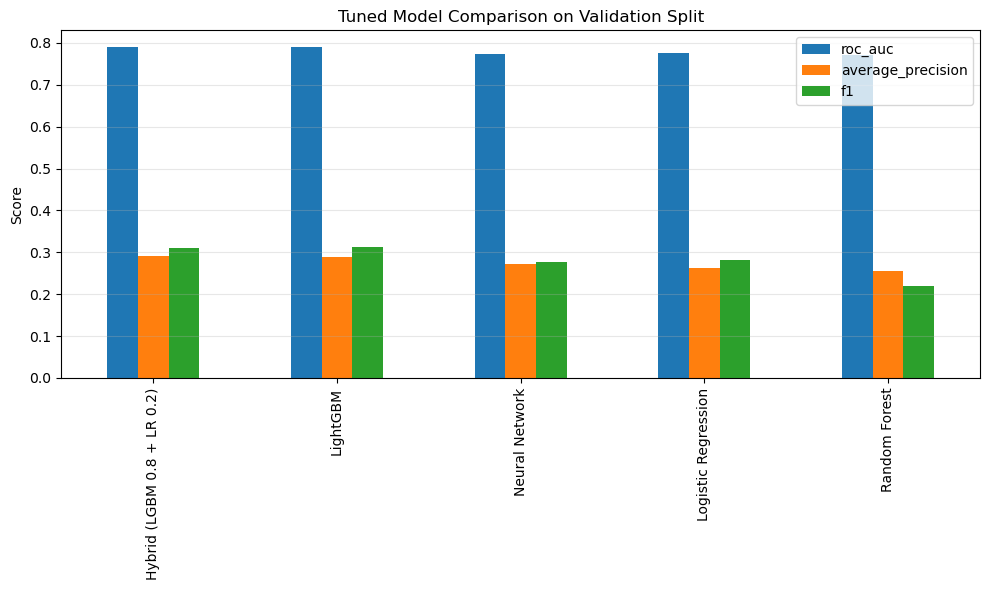

In [17]:
comparison_plot_df = results_df.set_index("model")[["roc_auc", "average_precision", "f1"]]

ax = comparison_plot_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Tuned Model Comparison on Validation Split")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

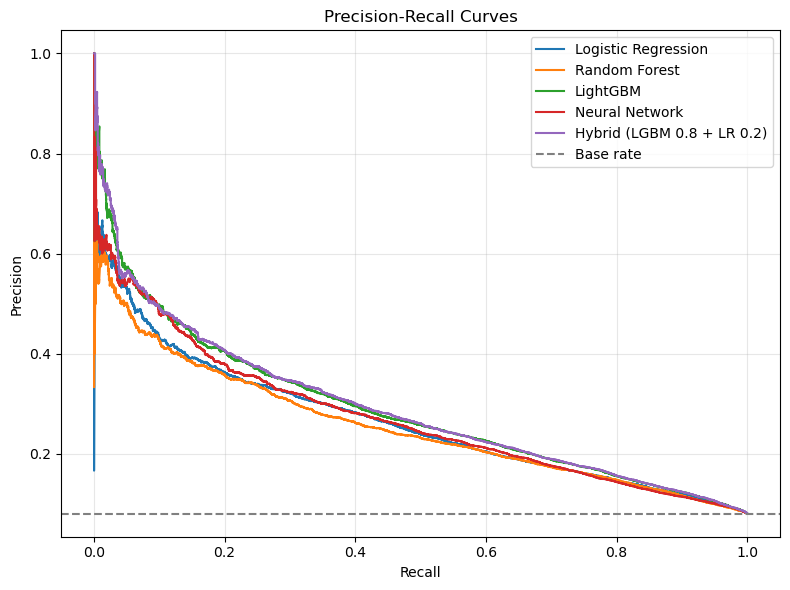

In [18]:
curve_dfs = {
    "Logistic Regression": build_precision_recall_curve_df(y_val_log_reg, log_reg_probs),
    "Random Forest": build_precision_recall_curve_df(y_val_rf, rf_probs),
    "LightGBM": build_precision_recall_curve_df(y_val_lgbm, lgbm_probs),
    "Neural Network": build_precision_recall_curve_df(y_val_mlp, mlp_probs),
    hybrid_results["model"]: build_precision_recall_curve_df(hybrid_y_val, hybrid_probs),
}

plt.figure(figsize=(8, 6))
for model_name, curve_df in curve_dfs.items():
    plt.plot(curve_df["recall"], curve_df["precision"], label=model_name)

baseline_precision = y_val_lgbm.mean()
plt.axhline(baseline_precision, linestyle="--", color="gray", label="Base rate")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "precision_recall_curves.png", dpi=200, bbox_inches="tight")
plt.show()

In [19]:
pd.DataFrame([
    find_threshold_for_target_precision(y_val_lgbm, lgbm_probs, target_precision=0.30),
    find_threshold_for_target_precision(hybrid_y_val, hybrid_probs, target_precision=0.30),
], index=["LightGBM", hybrid_results["model"]])

,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
LightGBM,0.7,0.885046,0.314472,0.359315,0.335401,0.789275,0.288121
Hybrid (LGBM 0.8 + LR 0.2),0.7,0.885209,0.316775,0.364753,0.339075,0.790512,0.290986


## Short Conclusions

- All main models now receive actual hyperparameter tuning, with RF and the neural net tuned on grids designed to be comparable in breadth to LightGBM.
- Treat the hybrid model as the novel contribution and compare it directly against tuned standalone LightGBM and tuned standalone Logistic Regression.
- Use `model_metrics_tuned.csv` for the fairest overall comparison.
